In [1]:
from data import *
from plot import *

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/01/04 18:37:37 WARN Utils: Your hostname, Siddharths-MacBook-Air-3.local, resolves to a loopback address: 127.0.0.1; using 192.168.223.204 instead (on interface en0)
26/01/04 18:37:37 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/04 18:37:38 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
# plot config
plt.rcParams['figure.dpi'] = 300;
sns.set_theme(style="whitegrid", context="notebook", palette="muted");
plt.figure(figsize=(10, 6));
plt.tight_layout();

# seeds
seeds = [_ for _ in range(10)]
seed = seeds[1]

<Figure size 3000x1800 with 0 Axes>

Analyze missing values.

In [3]:
revenue_na = revenue.filter(
    F.col('units').isNull()).toPandas()
revenue_na.head()

26/01/04 18:38:10 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/04 18:38:10 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/04 18:38:10 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/01/04 18:38:11 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/04 18:38:11 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


,item_id,store_id,wm_yr_wk,d,dept_id,cat_id,state_id,units,date,weekday,...,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price


In [4]:
item_ids_sample = list(items.sample(15, random_state=seed)['item_id'])
store_ids_sample = list(stores.sample(3, random_state=seed)['store_id'])

In [5]:
items_stores_sample = revenue \
                .select('*') \
                .where(revenue['item_id'].isin(item_ids_sample) &
                        revenue['store_id'].isin(store_ids_sample)) \
                .toPandas()


26/01/04 18:39:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/04 18:39:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/04 18:39:58 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/04 18:39:58 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/04 18:40:28 WARN DAGScheduler: Broadcasting large task binary with size 1366.8 KiB


/var/folders/q5/rll74k_j0qs7l4zzzgg749km0000gn/T/ipykernel_21478/2634874127.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['_d'] = data['d'].map(lambda x: int(x[2:]))


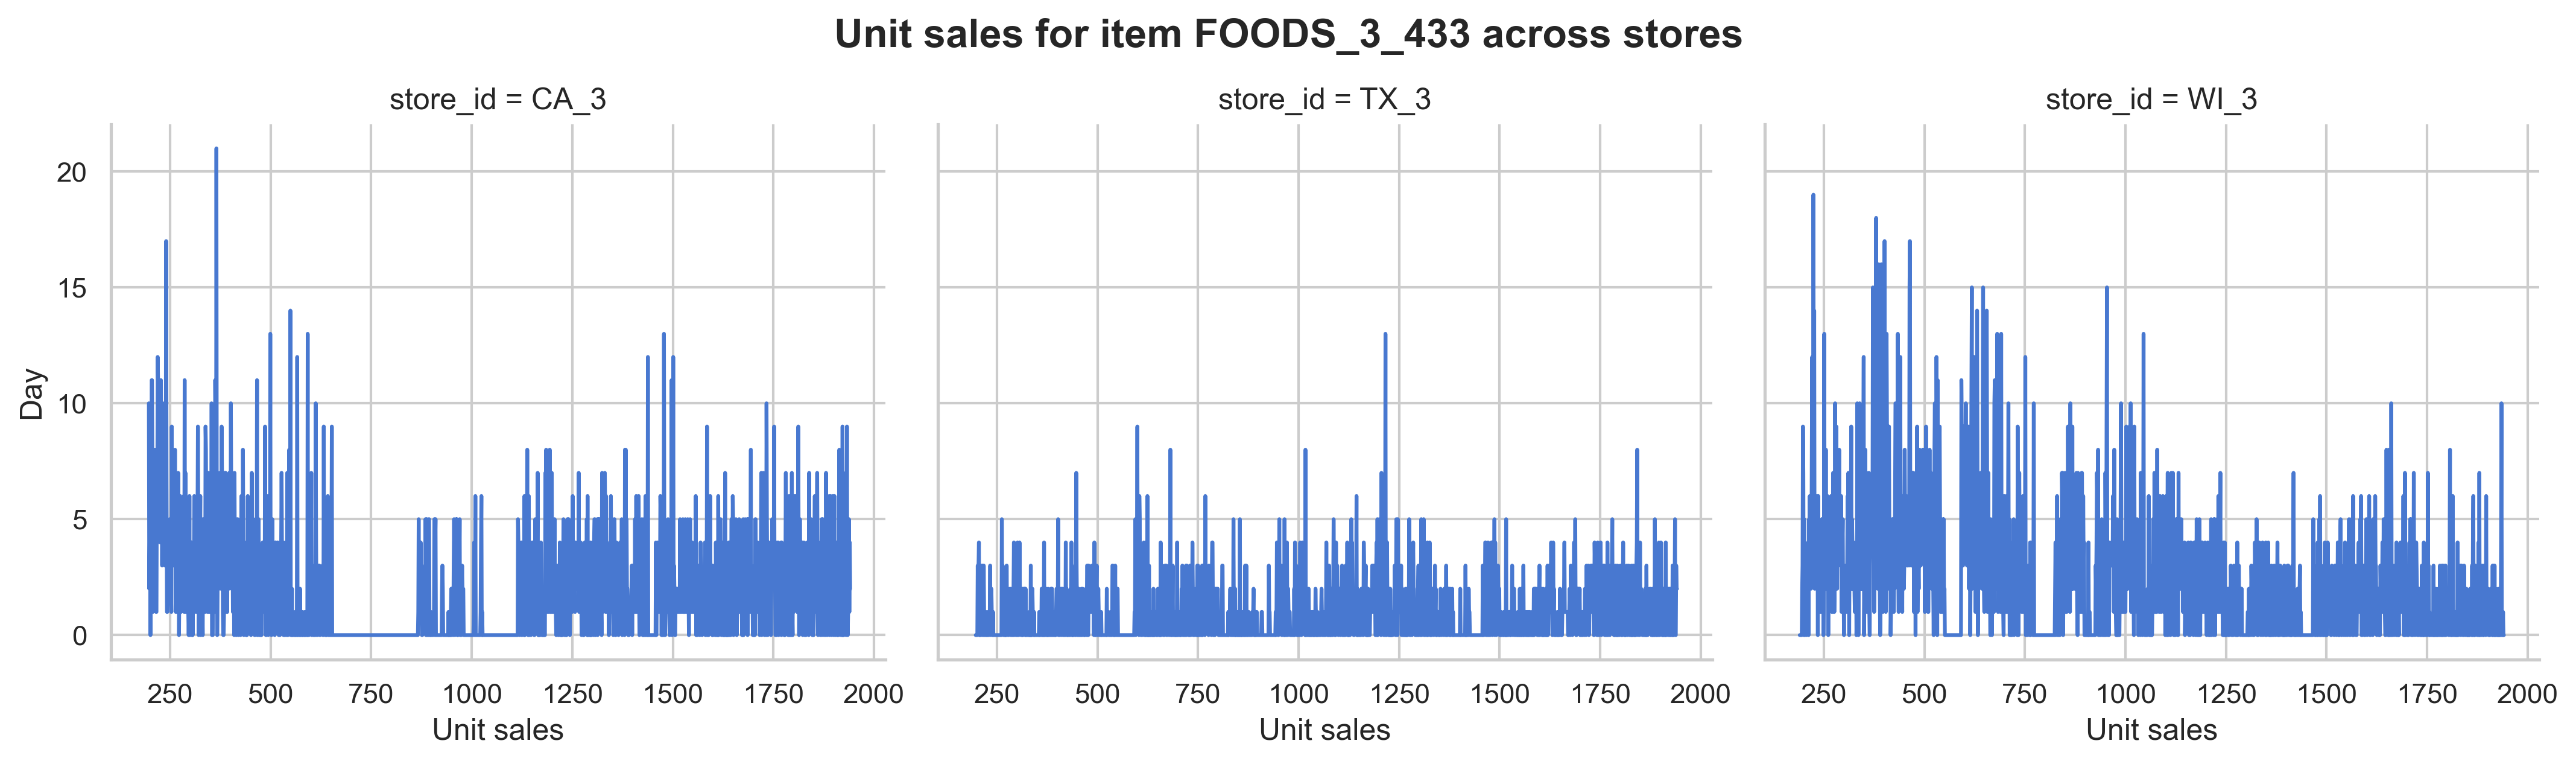

In [6]:
data = items_stores_sample[(items_stores_sample['item_id'] == item_ids_sample[0])]
data['_d'] = data['d'].map(lambda x: int(x[2:]))
data.sort_values(by=['_d', 'store_id', 'item_id'])

g = plot_panel(data, '_d', 
               'units', 
               'store_id', 
               f'Unit sales for item {item_ids_sample[0]} across stores')

/var/folders/q5/rll74k_j0qs7l4zzzgg749km0000gn/T/ipykernel_21478/2135674108.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['_d'] = data['d'].map(lambda x: int(x[2:]))


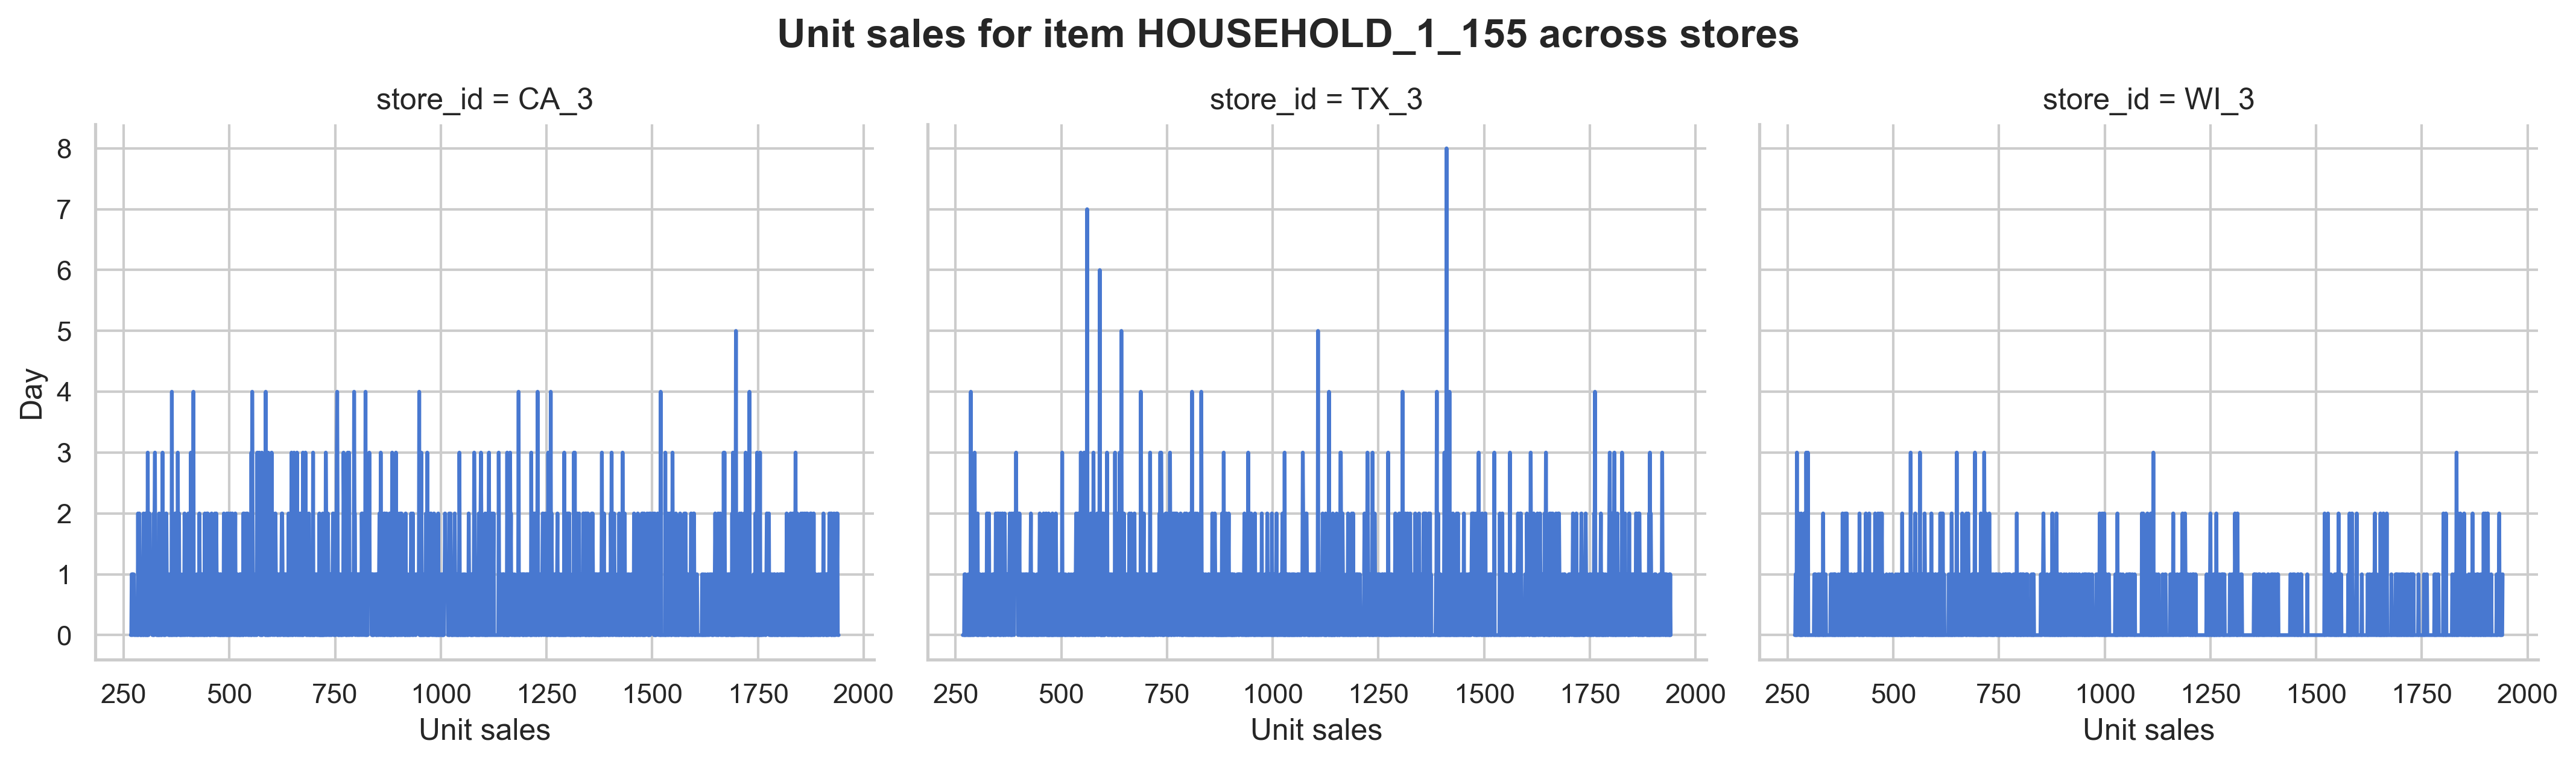

In [7]:
data = items_stores_sample[(items_stores_sample['item_id'] == item_ids_sample[1])]
data['_d'] = data['d'].map(lambda x: int(x[2:]))
data.sort_values(by=['_d', 'store_id', 'item_id'])
                        
g = plot_panel(data, '_d', 
               'units', 
               'store_id', 
               f'Unit sales for item {item_ids_sample[1]} across stores')

/var/folders/q5/rll74k_j0qs7l4zzzgg749km0000gn/T/ipykernel_21478/2233328555.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['_d'] = data['d'].map(lambda x: int(x[2:]))


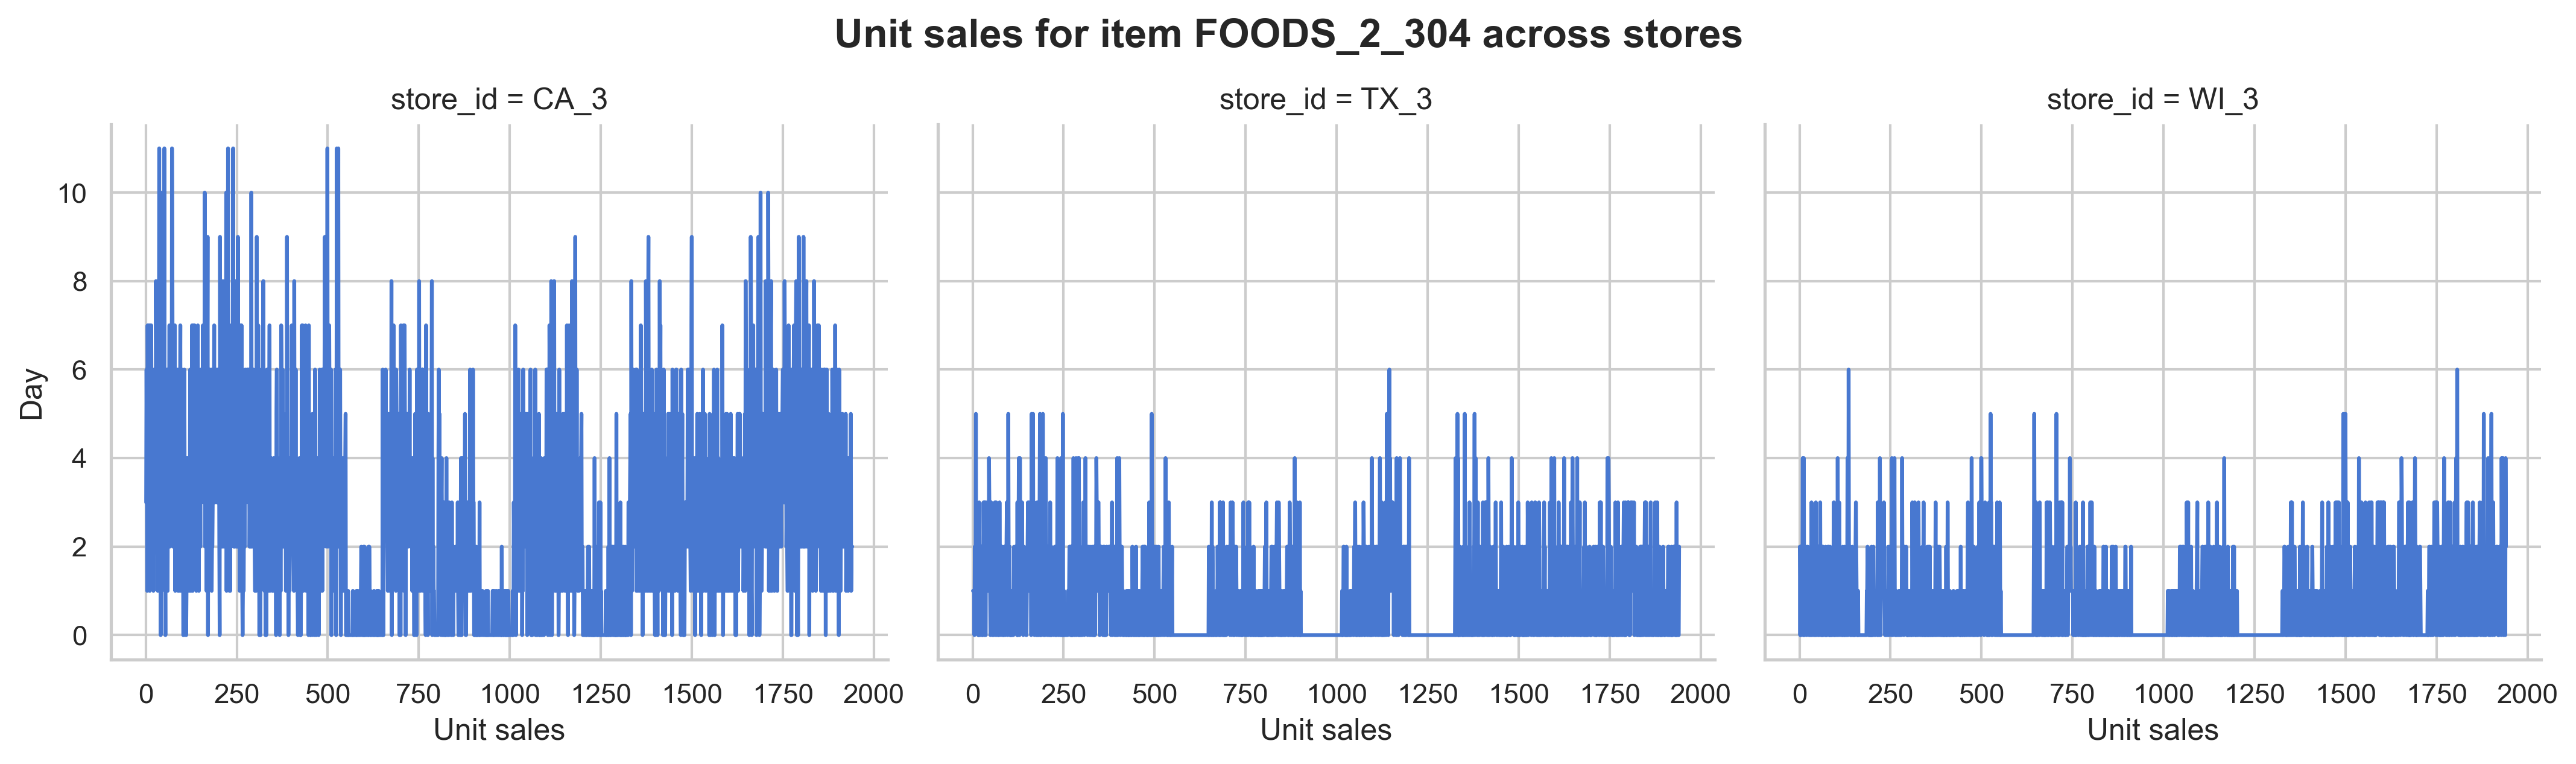

In [8]:
data = items_stores_sample[(items_stores_sample['item_id'] == item_ids_sample[2])]
data['_d'] = data['d'].map(lambda x: int(x[2:]))
data.sort_values(by=['_d', 'store_id', 'item_id'])
                        
g = plot_panel(data, '_d', 
               'units', 
               'store_id', 
               f'Unit sales for item {item_ids_sample[2]} across stores')

In [9]:
items_states_sample = revenue \
                .select('*') \
                .where(revenue['item_id'].isin(item_ids_sample) &
                        revenue['store_id'].isin(store_ids_sample)) \
                .groupBy('state_id', 'item_id', 'd').sum() \
                .toPandas()

26/01/04 18:40:47 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/04 18:40:47 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/04 18:40:48 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/04 18:40:48 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/04 18:41:11 WARN DAGScheduler: Broadcasting large task binary with size 1162.4 KiB
26/01/04 18:41:17 WARN DAGScheduler: Broadcasting large task binary with size 1162.9 KiB


In [10]:
items_states_sample

,state_id,item_id,d,sum(units),sum(sell_price)
0,CA,HOUSEHOLD_2_176,d_1228,4,4.97
1,CA,HOUSEHOLD_2_390,d_1497,0,5.98
2,CA,HOUSEHOLD_2_513,d_1357,2,2.78
3,CA,HOUSEHOLD_2_383,d_582,1,4.27
4,CA,HOUSEHOLD_1_155,d_430,1,3.47
...,...,...,...,...,...
73340,WI,HOUSEHOLD_2_383,d_1871,0,3.88
73341,WI,HOUSEHOLD_2_293,d_636,0,6.97
73342,WI,HOUSEHOLD_2_293,d_816,0,6.97
73343,WI,HOUSEHOLD_2_293,d_1435,0,7.47


In [11]:
items_total = revenue \
                .select('*') \
                .where(revenue['item_id'].isin(item_ids_sample)) \
                .groupBy('item_id', 'd').sum() \
                .toPandas()

26/01/04 18:41:19 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/04 18:41:19 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/04 18:41:21 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/04 18:41:21 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/04 18:41:42 WARN DAGScheduler: Broadcasting large task binary with size 1067.1 KiB
26/01/04 18:41:53 WARN DAGScheduler: Broadcasting large task binary with size 1059.8 KiB


In [12]:
items_total

,item_id,d,sum(units),sum(sell_price)
0,FOODS_1_102,d_239,5,17.80
1,FOODS_1_102,d_216,10,16.40
2,FOODS_2_218,d_1215,4,38.70
3,FOODS_2_218,d_172,5,27.54
4,FOODS_2_218,d_1600,7,39.16
...,...,...,...,...
25036,HOUSEHOLD_2_513,d_779,0,2.78
25037,HOUSEHOLD_1_332,d_1057,3,48.70
25038,HOUSEHOLD_1_332,d_1053,1,48.70
25039,HOUSEHOLD_1_332,d_1054,0,48.70


In [13]:
dept_stores_sample = revenue \
                .select('*') \
                .where(revenue['store_id'].isin(store_ids_sample)) \
                .groupBy('dept_id', 'store_id', 'd').sum() \
                .toPandas()

26/01/04 18:41:54 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/04 18:41:54 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/04 18:41:55 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/04 18:41:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/04 18:42:57 WARN DAGScheduler: Broadcasting large task binary with size 1170.6 KiB
26/01/04 18:43:07 WARN TaskMemoryManager: Failed to allocate a page (16777216 bytes), try again.
26/01/04 18:43:25 WARN DAGScheduler: Broadcasting large task binary with size 1163.1 KiB


In [14]:
dept_stores_sample

,dept_id,store_id,d,sum(units),sum(sell_price)
0,FOODS_1,WI_3,d_1188,114,725.36
1,FOODS_1,WI_3,d_1849,285,760.48
2,FOODS_1,CA_3,d_266,244,449.49
3,FOODS_1,CA_3,d_1021,294,658.63
4,FOODS_1,CA_3,d_1316,334,685.14
...,...,...,...,...,...
40756,HOUSEHOLD_2,TX_3,d_279,113,1991.32
40757,HOUSEHOLD_2,WI_3,d_1747,101,2980.03
40758,HOUSEHOLD_2,WI_3,d_1357,57,2900.43
40759,HOUSEHOLD_2,TX_3,d_712,53,2330.51


In [15]:
cat_stores_sample = revenue \
                .select('*') \
                .where(revenue['store_id'].isin(store_ids_sample)) \
                .groupBy('cat_id', 'store_id').sum() \
                .toPandas()

26/01/04 18:43:27 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/04 18:43:27 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/04 18:43:29 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/04 18:43:29 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/04 18:44:27 WARN DAGScheduler: Broadcasting large task binary with size 1169.6 KiB
26/01/04 18:44:51 WARN DAGScheduler: Broadcasting large task binary with size 1162.2 KiB


In [16]:
items_states_sample

,state_id,item_id,d,sum(units),sum(sell_price)
0,CA,HOUSEHOLD_2_176,d_1228,4,4.97
1,CA,HOUSEHOLD_2_390,d_1497,0,5.98
2,CA,HOUSEHOLD_2_513,d_1357,2,2.78
3,CA,HOUSEHOLD_2_383,d_582,1,4.27
4,CA,HOUSEHOLD_1_155,d_430,1,3.47
...,...,...,...,...,...
73340,WI,HOUSEHOLD_2_383,d_1871,0,3.88
73341,WI,HOUSEHOLD_2_293,d_636,0,6.97
73342,WI,HOUSEHOLD_2_293,d_816,0,6.97
73343,WI,HOUSEHOLD_2_293,d_1435,0,7.47


/var/folders/q5/rll74k_j0qs7l4zzzgg749km0000gn/T/ipykernel_21478/1284528491.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['_d'] = data['d'].map(lambda x: int(x[2:]))


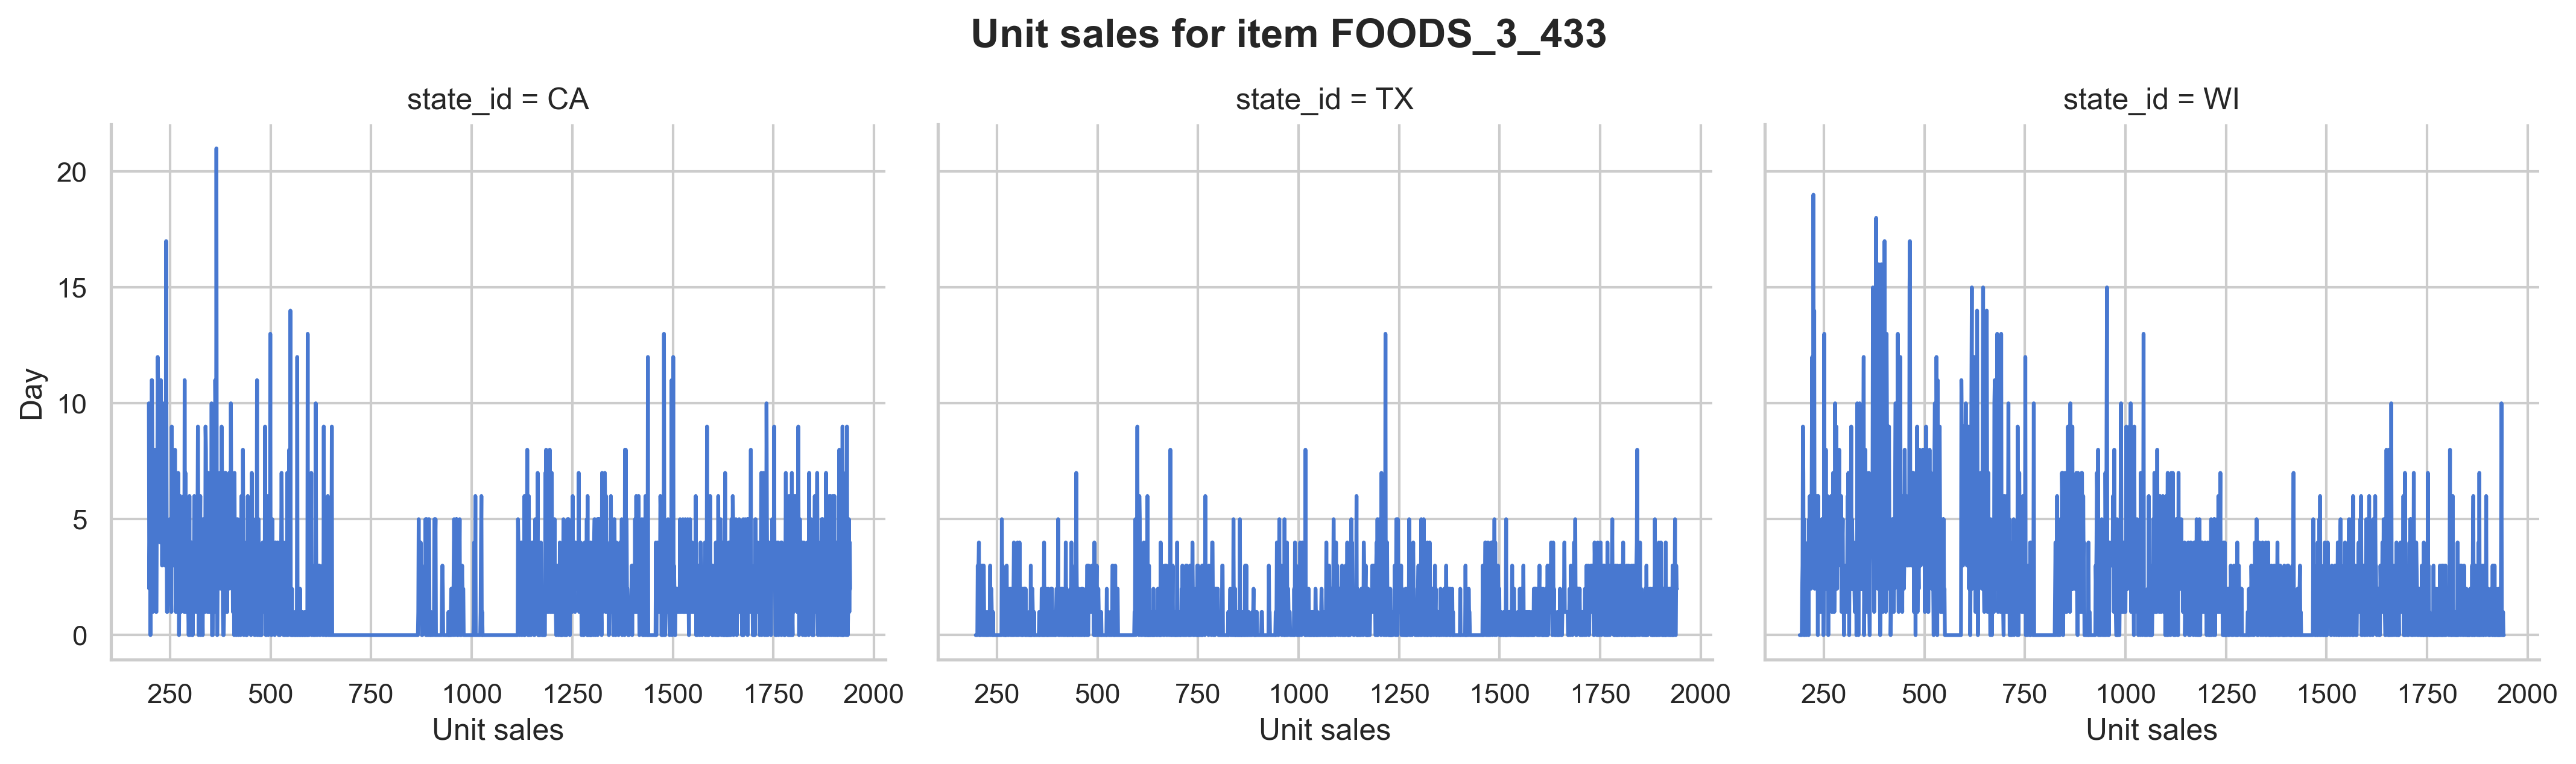

In [17]:
data = items_states_sample[(items_states_sample['item_id'] == item_ids_sample[0])]
data['_d'] = data['d'].map(lambda x: int(x[2:]))
data.sort_values(by=['_d', 'state_id', 'item_id'])
                        
g = plot_panel(data, '_d', 
               'sum(units)', 
               'state_id', 
               f'Unit sales for item {item_ids_sample[0]}')

/var/folders/q5/rll74k_j0qs7l4zzzgg749km0000gn/T/ipykernel_21478/3574229265.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['_d'] = data['d'].map(lambda x: int(x[2:]))


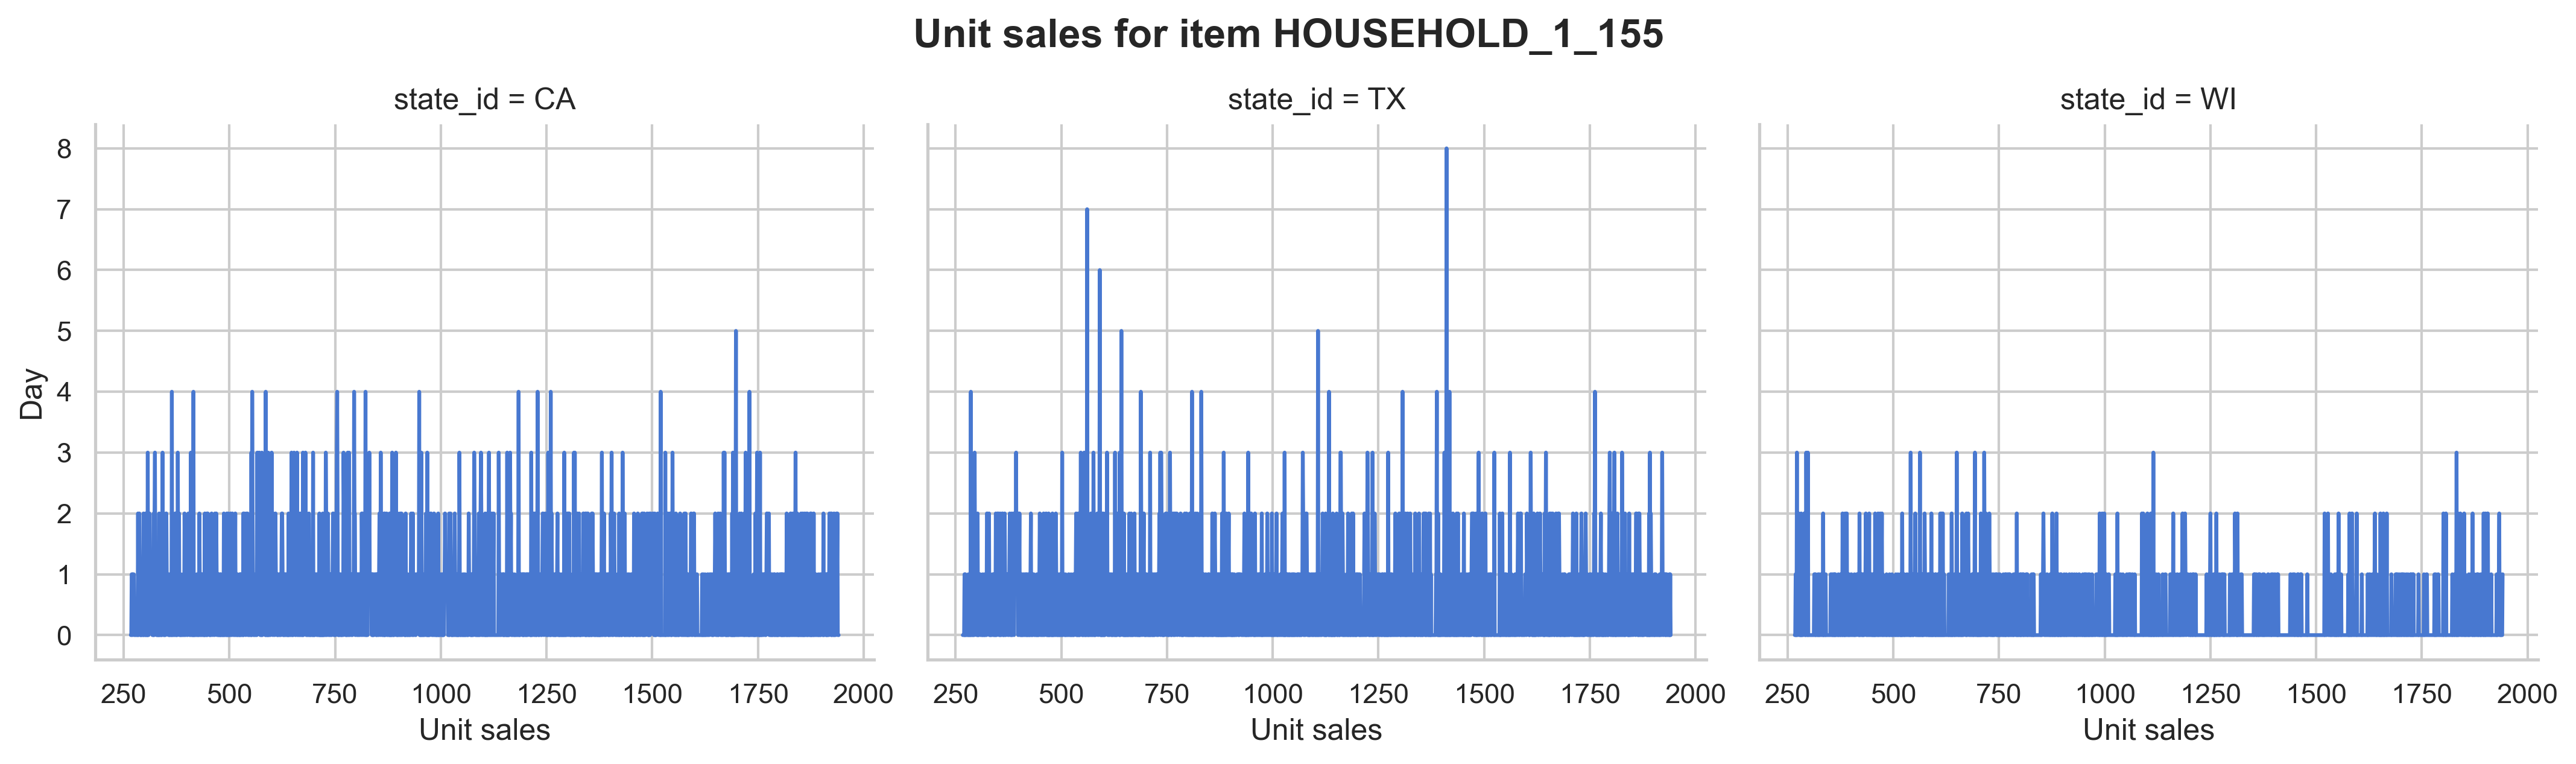

In [18]:
data = items_states_sample[(items_states_sample['item_id'] == item_ids_sample[1])]
data['_d'] = data['d'].map(lambda x: int(x[2:]))
data.sort_values(by=['_d', 'state_id', 'item_id'])
                        
g = plot_panel(data, '_d', 
               'sum(units)', 
               'state_id', 
               f'Unit sales for item {item_ids_sample[1]}')

/var/folders/q5/rll74k_j0qs7l4zzzgg749km0000gn/T/ipykernel_21478/2815940694.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['_d'] = data['d'].map(lambda x: int(x[2:]))


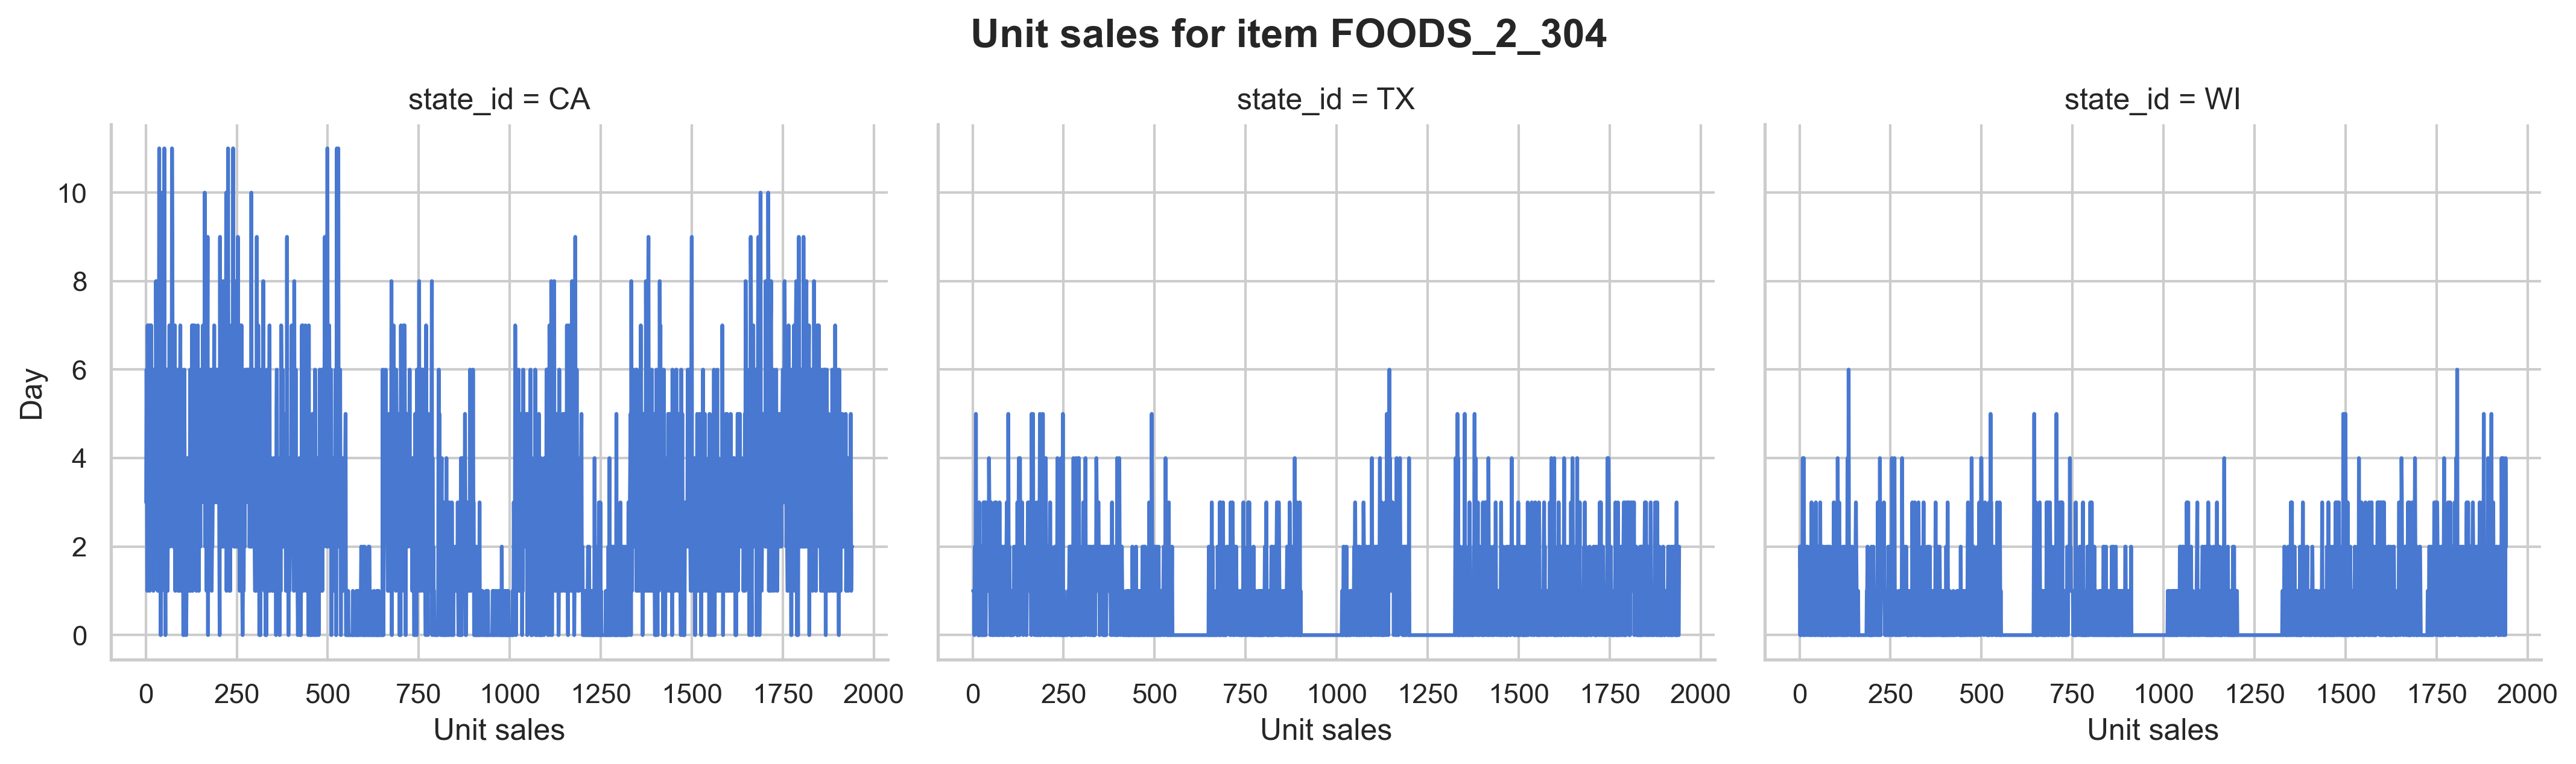

In [19]:
data = items_states_sample[(items_states_sample['item_id'] == item_ids_sample[2])]
data['_d'] = data['d'].map(lambda x: int(x[2:]))
data.sort_values(by=['_d', 'state_id', 'item_id'])
                        
g = plot_panel(data, '_d', 
               'sum(units)', 
               'state_id', 
               f'Unit sales for item {item_ids_sample[2]}')

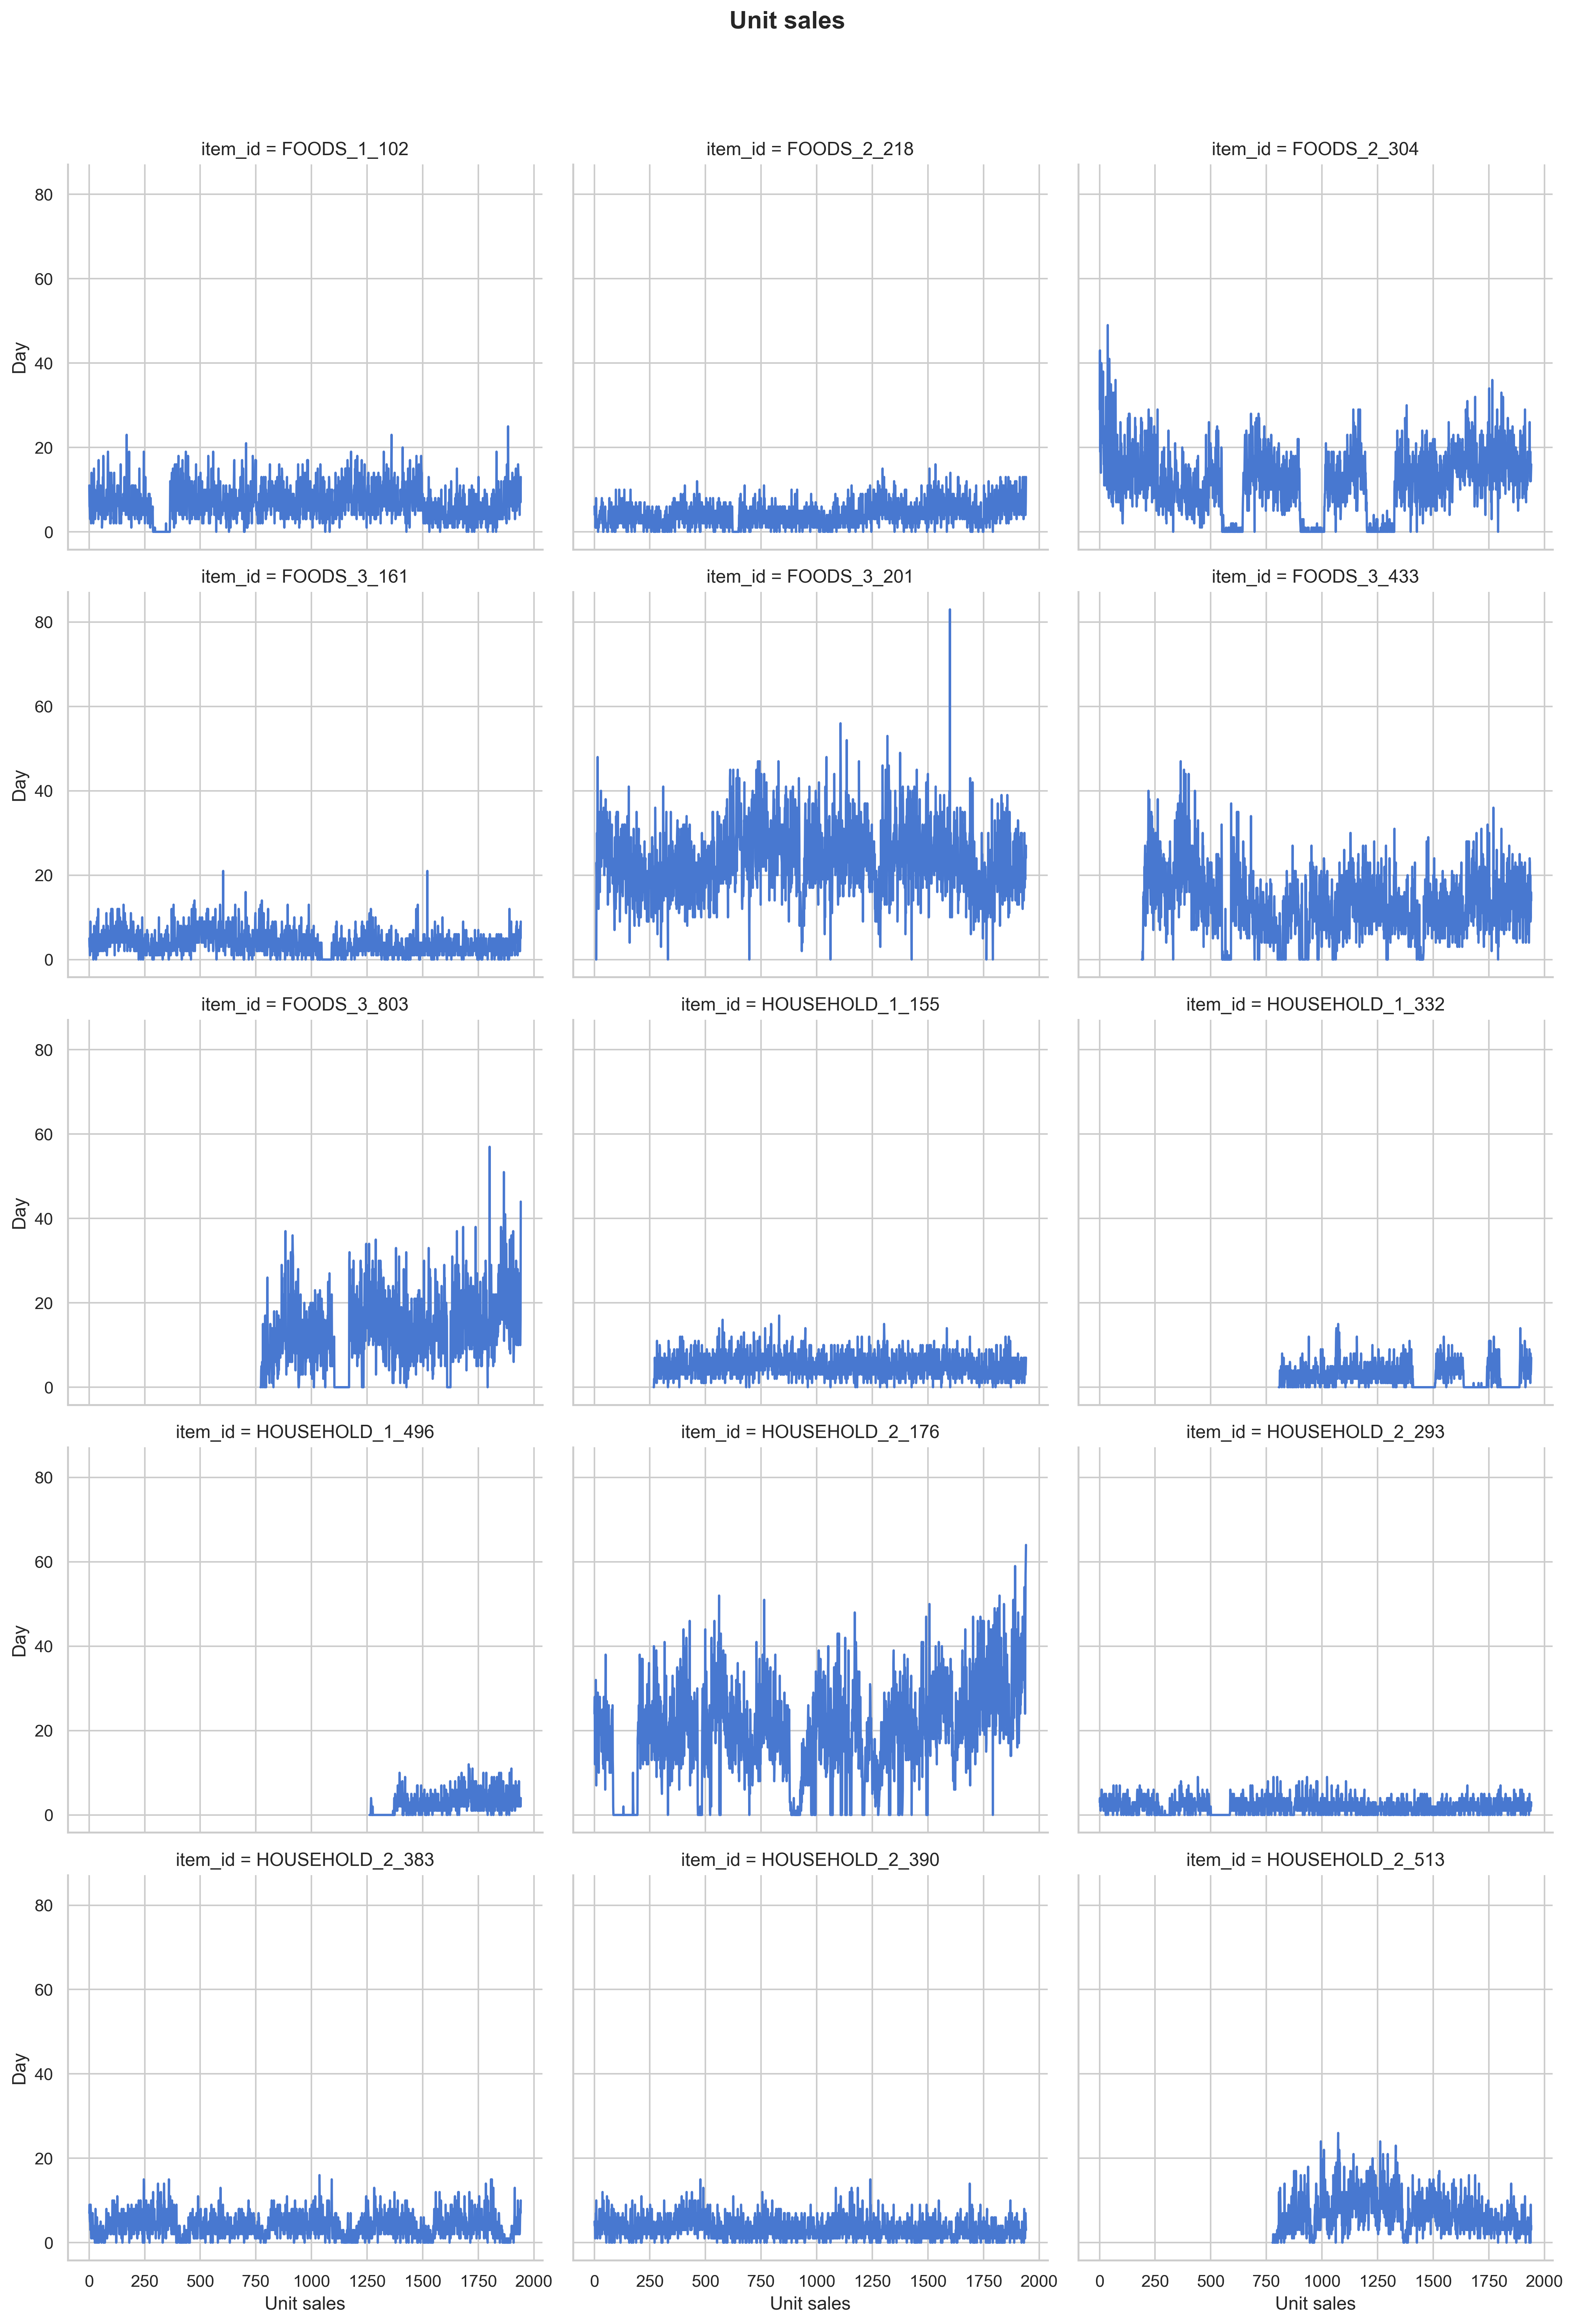

In [20]:
data = items_total
data['_d'] = data['d'].map(lambda x: int(x[2:]))
data.sort_values(by=['_d', 'item_id'])
                        
g = plot_panel(data, '_d', 
               'sum(units)', 
               'item_id', 
               f'Unit sales')

In [21]:
summary

,states,stores,categories,departments,items
0,3,10,3,7,3049


/var/folders/q5/rll74k_j0qs7l4zzzgg749km0000gn/T/ipykernel_21478/253764333.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['_d'] = data['d'].map(lambda x: int(x[2:]))


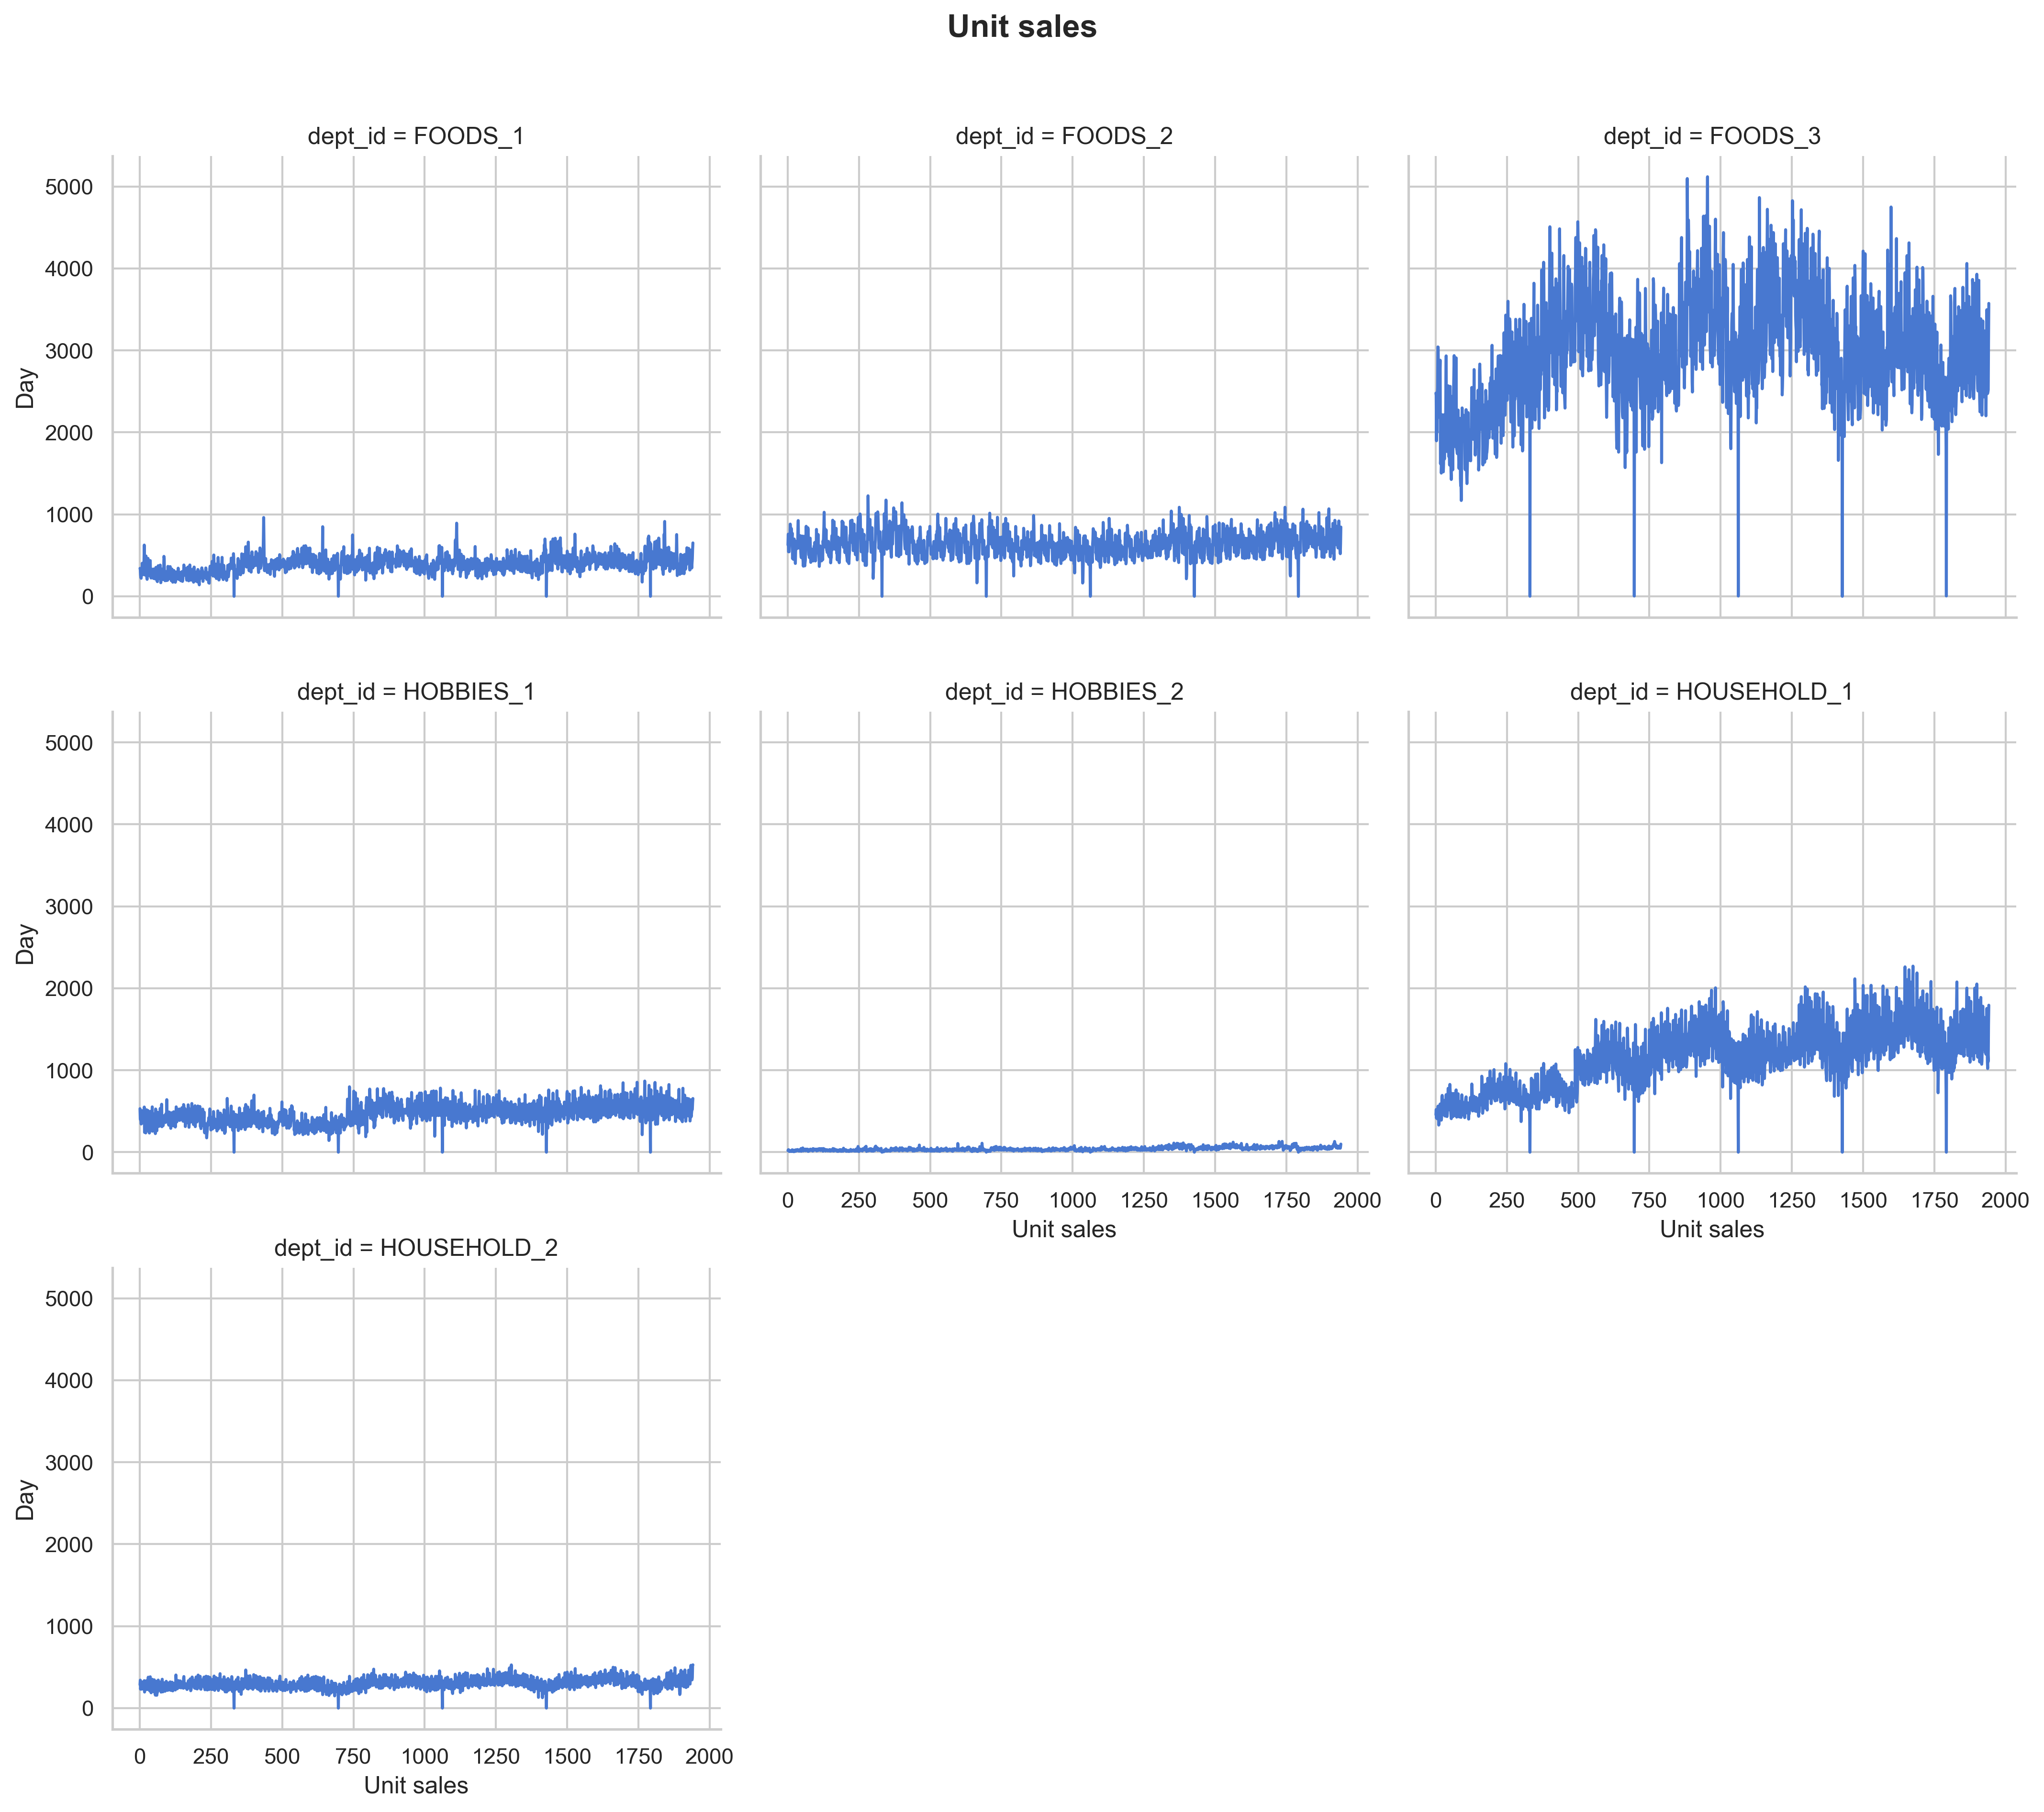

In [22]:
data = dept_stores_sample[(dept_stores_sample['store_id'] == store_ids_sample[0])]
data['_d'] = data['d'].map(lambda x: int(x[2:]))
data.sort_values(by=['_d', 'store_id', 'dept_id'])
                        
g = plot_panel(data, '_d', 
               'sum(units)', 
               'dept_id', 
               f'Unit sales')